# Biblioteka Matplotlib - Część 1

## Wprowadzenie do Matplotlib i jego struktury

W tej części poznasz podstawy Matplotlib: instalację, import, dwa style pracy (pyplot vs OO-style) oraz fundamentalną strukturę biblioteki - Figure, Axes, Axis i Artists.

## 1. Wprowadzenie do Matplotlib

**Matplotlib** https://matplotlib.org/ to biblioteka do tworzenia wykresów 2D (i 3D) w Pythonie. Jest to najpopularniejsze narzędzie do wizualizacji danych.

### Dlaczego Matplotlib?

- **Stabilność** - używana od 2003 roku
- **Elastyczność** - pełna kontrola nad każdym elementem
- **Kompatybilność** - działa z NumPy i Pandas
- **Standard** - większość innych bibliotek do wizualizacji bazuje na Matplotlib

### Instalacja

```bash
pip install matplotlib
```

In [1]:
!pip install matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


### Import biblioteki

Matplotlib importujemy zazwyczaj jako `plt` (przyjęta konwencja):

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ustawienie, żeby wykresy pokazywały się w notebooku
# %matplotlib widget  # requires `pip install ipympl`
%matplotlib inline

print("Matplotlib zaimportowany pomyślnie!")
print(f"Wersja: {plt.matplotlib.__version__}")

Matplotlib zaimportowany pomyślnie!
Wersja: 3.11.0


### Dwa style pracy z Matplotlib

Matplotlib oferuje dwa główne style programowania:

#### 1. Pyplot interface (MATLAB-style)

Prosty, szybki - dobry do eksploracji danych:

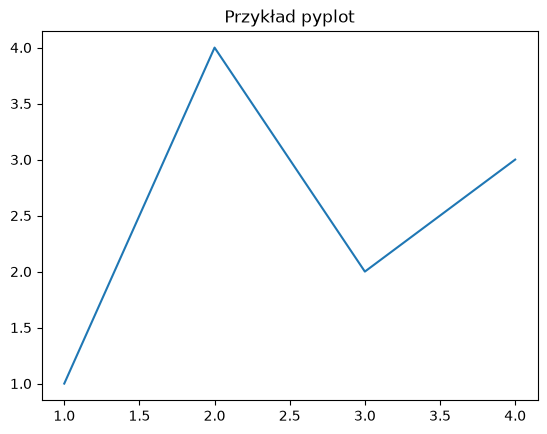

In [3]:
# Styl pyplot - prosty

X = [1, 2, 3, 4]
Y = [1, 4, 2, 3]

plt.plot(X, Y)
plt.title("Przykład pyplot")
plt.show()

Globalne funkcje działające na niejawnym 'aktualnym wykresie', który wyświetlamy funkcją `plt.show` - wygodne, ale ryzykowne przy wielu wykresach.

#### 2. Object-oriented interface (OO-style)

Bardziej kontrolowany - dobry do złożonych wykresów i skryptów:

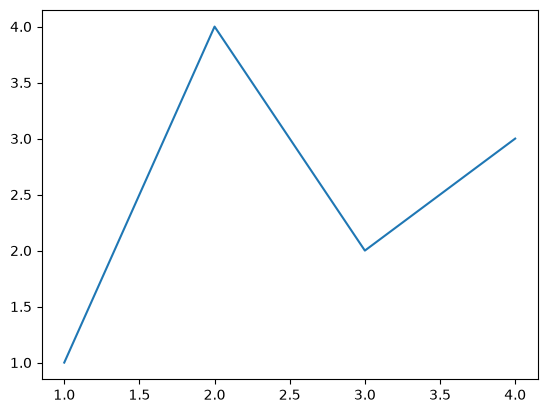

In [4]:
# Styl obiektowy - bardziej kontrolowany

X = [1, 2, 3, 4]
Y = [1, 4, 2, 3]

fig, ax = plt.subplots()
ax.plot(X, Y)
plt.show()

Jawne tworzenie i manipulowanie obiektami wykresów - pełna kontrola, klarowny kod, brak niespodzianek.

### 📝 Co zwraca `subplots()`?

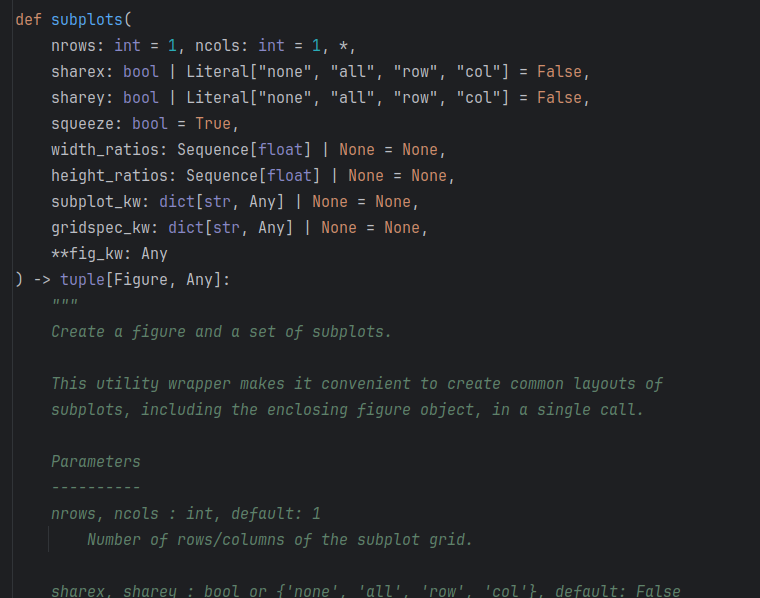

**Sygnatura funkcji:**
```python
subplots(...) -> tuple[Figure, Any]
```

**Co to znaczy?**

- **`Figure`** = całe "płótno" (kontener dla wykresów, okno z całym dashboardem)
- **`Any`** = jeden lub więcej obiektów `Axes` (konkretne wykresy)

**Dlaczego `Any`?** Bo zależy od parametrów:
- `subplots()` → zwraca **pojedynczy `Axes`** (jeden wykres)
- `subplots(2, 2)` → zwraca **tablicę `Axes`** o wymiarach 2×2 (4 wykresy)

**Analogia:**
- `Figure` = rama z obrazem (cały obiekt do powieszenia na ścianie)
- `Axes` = konkretny obrazek/wykres (może być jeden albo kilka w ramie)

**Przykłady:**
```python
# Jeden wykres
fig, ax = plt.subplots()
# fig = Figure, ax = pojedynczy Axes

# Grid 2x2 (4 wykresy)
fig, axes = plt.subplots(2, 2)
# fig = Figure, axes = tablica 2x2 obiektów Axes
# axes[0,0], axes[0,1], axes[1,0], axes[1,1]
```



---

**Rekomendacja:** Używaj stylu **object-oriented** - daje więcej kontroli i jest łatwiejszy do debugowania.

W tym notebooku będziemy używać głównie stylu OO.

---

**💡 Chcesz dowiedzieć się więcej o różnicy między pyplot a OO-style?**

Przejdź do **[matplotlib_faq.ipynb](matplotlib_faq.ipynb)** - sekcja 1: "Pyplot vs OO-style - jaka jest różnica?"  
Tam znajdziesz:
- Szczegółowe wyjaśnienie różnicy STATEFUL vs STATELESS
- Praktyczne przykłady pokazujące problemy z pyplot przy wielu wykresach
- Tabelę porównawczą wszystkich różnic
- Rekomendacje kiedy używać którego stylu

---

Podczas poznawania matplotlib pomocna będzie ilustracja prezentująca poszczególne elementy wykresu

<div style="text-align: center;">                                                                                        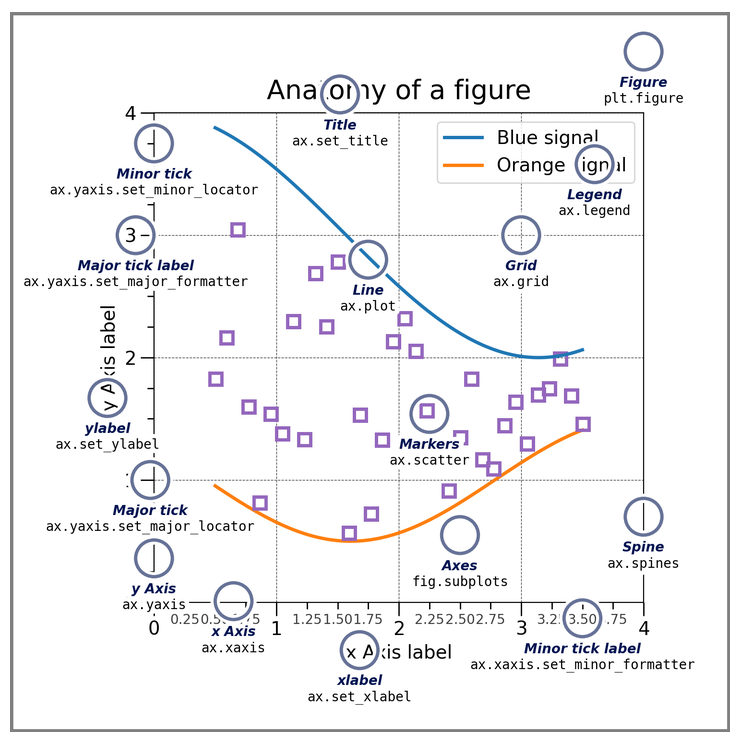                                            <p style="font-style: italic; color: #666; margin-top: 5px; text-align: center;"><a href="https://matplotlib.org/stable/users/explain/quick_start.html#parts-of-a-figure">Parts of the Figure - Matplotlib Documentation</a>
  </p>
</div>     

### Praktyczny przykład - eksplorujemy strukturę

Zobaczmy jak dostać się do różnych elementów wykresu w praktyce:

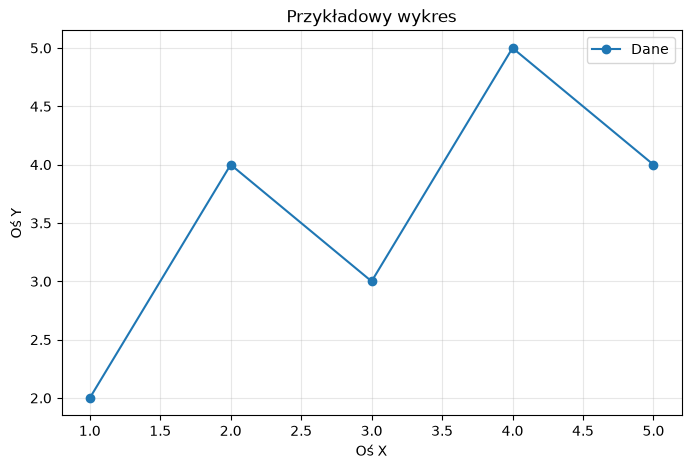

In [55]:
# === PRZYKŁAD: Eksplorujemy strukturę wykresu ===

# 1. Tworzymy prosty wykres
fig, ax = plt.subplots(figsize=(8, 5))
x = [1, 2, 3, 4, 5]
y = [2, 4, 3, 5, 4]

line, = ax.plot(x, y, marker='o', label="Dane")

ax.set_title('Przykładowy wykres')
ax.set_xlabel("Oś X")
ax.set_ylabel("Oś Y")
ax.legend()
ax.grid(alpha=0.3)

**💡 Co oznacza `figsize=(8, 5)`? Co to jest DPI?**

Przejdź do **[matplotlib_faq.ipynb](matplotlib_faq.ipynb)** - sekcja 3: "Co oznacza figsize i DPI?"  
Tam znajdziesz:
- Szczegółowe wyjaśnienie parametrów `figsize` (rozmiar w calach)
- Co to jest DPI w matplotlib i jak wpływa na rozmiar obrazu
- Różnica między DPI matplotlib a DPI ekranu
- Rozdzielczość fizyczna vs systemowa
- Jak wykres wyświetla się na różnych ekranach

---

#### 🤔 Dlaczego `line, = ax.plot(...)` z przecinkiem?

**Odpowiedź:** `ax.plot()` **zawsze zwraca listę** obiektów Line2D, nawet gdy rysujemy jedną linię!

**Dlaczego lista?** Bo `plot()` może narysować **wiele linii jednocześnie**:
```python
# Jedna funkcja, 3 linie naraz!
lines = ax.plot(x1, y1,    # linia 1
                x2, y2,    # linia 2
                x3, y3)    # linia 3
# Zwraca: [Line2D, Line2D, Line2D]
```

Dla spójności API **zawsze zwraca listę**, nawet gdy jest tylko 1 element.

**Co robi `line, = ...`?**
- `ax.plot(x, y)` zwraca `[Line2D_object]` (lista z 1 elementem!)
- `line,` = **unpacking** - wyciąga pierwszy element z listy
- Przecinek oznacza: "rozpakuj listę do jednej zmiennej"

**Alternatywa:**
```python
# Z przecinkiem (unpacking)
line, = ax.plot(x, y)  
line.set_color('red')  # ✅ OK! Masz obiekt Line2D

# Lub indeksowanie
line = ax.plot(x, y)[0]  # ✅ Też działa, ale mniej eleganckie
```

💡 **Wniosek:** Przecinek to unpacking - wyciąga obiekt z listy

---

🔍 EKSPLORUJEMY STRUKTURĘ WYKRESU

In [56]:
# === 1. FIGURE ===
print("\n1️⃣ FIGURE (płótno):")
print(f"   Typ: {type(fig)}")
print(f"   Umiejętności płótna: \n{dir(fig)}")


1️⃣ FIGURE (płótno):
   Typ: <class 'matplotlib.figure.Figure'>
   Umiejętności płótna: 
['_PROPERTIES_EXCLUDED_FROM_SET', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_add_axes_internal', '_agg_filter', '_align_label_groups', '_alpha', '_animated', '_axobservers', '_axstack', '_button_pick_id', '_callbacks', '_canvas_callbacks', '_check_layout_engines_compat', '_clipon', '_clippath', '_cm_set', '_different_canvas', '_dpi', '_fully_clipped_to_axes', '_gci', '_get_dpi', '_get_draw_artists', '_get_in_autoscale', '_get_renderer', '_gid', '_in_autoscale', '_in_layout', '_internal_update', '_label', '_layout_engine', '_l

In [57]:
print(f"   Rozmiar: {fig.get_figwidth():.1f} x {fig.get_figheight():.1f} cali")
print(f"   DPI (rozdzielczość): {fig.dpi}")
print(f"   Liczba Axes na Figure: {len(fig.axes)}")
print(f"   Lista wykresów {fig.axes}")

   Rozmiar: 8.0 x 5.0 cali
   DPI (rozdzielczość): 100.0
   Liczba Axes na Figure: 1
   Lista wykresów [<Axes: title={'center': 'Przykładowy wykres'}, xlabel='Oś X', ylabel='Oś Y'>]


In [58]:
# === 2. AXES ===
# W języku angielskim `axes` to liczba mnoga od `axis`, ale w matplotlib oznacza po prostu wykres.
print("\n2️⃣ AXES (wykres):")
print(f"   Typ: {type(ax)}")
print(f"   Umiejętności wykresu: \n{dir(ax)}")


2️⃣ AXES (wykres):
   Typ: <class 'matplotlib.axes._axes.Axes'>
   Umiejętności wykresu: 
['ArtistList', '_AxesBase__clear', '_PROPERTIES_EXCLUDED_FROM_SET', '__annotate_func__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_add_text', '_adjustable', '_agg_filter', '_alias_to_prop', '_alpha', '_anchor', '_animated', '_aspect', '_autotitlepos', '_axes', '_axes_locator', '_axis_map', '_axis_names', '_axisbelow', '_box_aspect', '_callbacks', '_check_no_units', '_children', '_clipon', '_clippath', '_cm_set', '_colorbars', '_convert_dx', '_current_image', '_different_canvas', '_errorevery_to_mask', '_facecolor', '_fill_b

In [59]:
print(f"   Tytuł: '{ax.get_title()}'")
print(f"   Xlabel: '{ax.get_xlabel()}'")
print(f"   Ylabel: '{ax.get_ylabel()}'")

# Sprawdźmy czy ax i fig.axes[0] to ten sam obiekt
print(f"   ax === fig.axes[0]: {ax is fig.axes[0]}")  # True!

   Tytuł: 'Przykładowy wykres'
   Xlabel: 'Oś X'
   Ylabel: 'Oś Y'
   ax === fig.axes[0]: True


In [60]:
# === 3. AXIS ===
print("\n3️⃣ AXIS (osie X i Y):")
print(f"   ax.xaxis typ: {type(ax.xaxis)}")
print(f"   ax.yaxis typ: {type(ax.yaxis)}")
print(f"   Umiejętności osi X \n{dir(ax.xaxis)}")


3️⃣ AXIS (osie X i Y):
   ax.xaxis typ: <class 'matplotlib.axis.XAxis'>
   ax.yaxis typ: <class 'matplotlib.axis.YAxis'>
   Umiejętności osi X 
['OFFSETTEXTPAD', '_PROPERTIES_EXCLUDED_FROM_SET', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__name__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_agg_filter', '_alpha', '_animated', '_autolabelpos', '_autoscale_on', '_axes', '_callbacks', '_clipon', '_clippath', '_cm_set', '_converter', '_converter_is_explicit', '_copy_tick_props', '_different_canvas', '_format_with_dict', '_fully_clipped_to_axes', '_get_autoscale_on', '_get_axis_name', '_get_in_autoscale', '_get_shared_axes', '_get_shared_axis', '_get_tick', '_get_tick_boxes_

In [61]:
print(f"   Zakresy:")
print(f"     - Oś X: {ax.get_xlim()}")
print(f"     - Oś Y: {ax.get_ylim()}")

   Zakresy:
     - Oś X: (np.float64(0.8), np.float64(5.2))
     - Oś Y: (np.float64(1.85), np.float64(5.15))


In [63]:
print(type(line))
print(dir(line))

<class 'matplotlib.lines.Line2D'>
['_PROPERTIES_EXCLUDED_FROM_SET', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_agg_filter', '_alias_to_prop', '_alpha', '_animated', '_antialiased', '_axes', '_callbacks', '_clipon', '_clippath', '_cm_set', '_color', '_dash_pattern', '_dashcapstyle', '_dashjoinstyle', '_different_canvas', '_drawStyles_l', '_drawStyles_s', '_drawstyle', '_fully_clipped_to_axes', '_gapcolor', '_get_in_autoscale', '_get_markerfacecolor', '_get_transformed_path', '_gid', '_in_autoscale', '_in_layout', '_internal_update', '_invalidx', '_invalidy', '_label', '_lineStyles', '_linestyle', '_linestyles', '_linewidth', '_mar

In [65]:
# === 4. ARTISTS ===
print("\n4️⃣ ARTISTS (elementy wykresu):")
print(f"   Linia (line) typ: {type(line)}")
print(f"   Kolor linii: {line.get_color()}")
print(f"   Szerokość linii: {line.get_linewidth()}")
print(f"   Marker: '{line.get_marker()}'")

# Wszystkie Artists na Axes
print(f"\n   Liczba wszystkich Artists na Axes: {len(ax.get_children())}")
print(f"   Typy Artists:")
for i, artist in enumerate(ax.get_children()):
    print(f"     {i+1}. {type(artist).__name__}")

print("\n" + "=" * 70)
print("✅ Widzisz? Każdy element ma swoją strukturę i możesz go kontrolować!")
print("=" * 70)


4️⃣ ARTISTS (elementy wykresu):
   Linia (line) typ: <class 'matplotlib.lines.Line2D'>
   Kolor linii: (0.12156862745098039, 0.4666666666666667, 0.7058823529411765)
   Szerokość linii: 1.5
   Marker: 'o'

   Liczba wszystkich Artists na Axes: 12
   Typy Artists:
     1. Line2D
     2. Spine
     3. Spine
     4. Spine
     5. Spine
     6. XAxis
     7. YAxis
     8. Text
     9. Text
     10. Text
     11. Legend
     12. Rectangle

✅ Widzisz? Każdy element ma swoją strukturę i możesz go kontrolować!


---

**💡 Chcesz dowiedzieć się więcej o typach Artists?**

Przejdź do **[matplotlib_faq.ipynb](../matplotlib_faq.ipynb)** - sekcja 2: "Jakie są typy Artists i do czego służą?"  
Tam znajdziesz:
- Przegląd wszystkich podstawowych typów Artists (Line2D, Patch, Text, itp.)
- Wizualizacje poszczególnych Artists w izolacji
- Przykłady manipulacji każdym typem
- Tabela porównawcza

---

### Wizualizacja czterech spine

🎨 Wizualizacja każdego Spine osobno



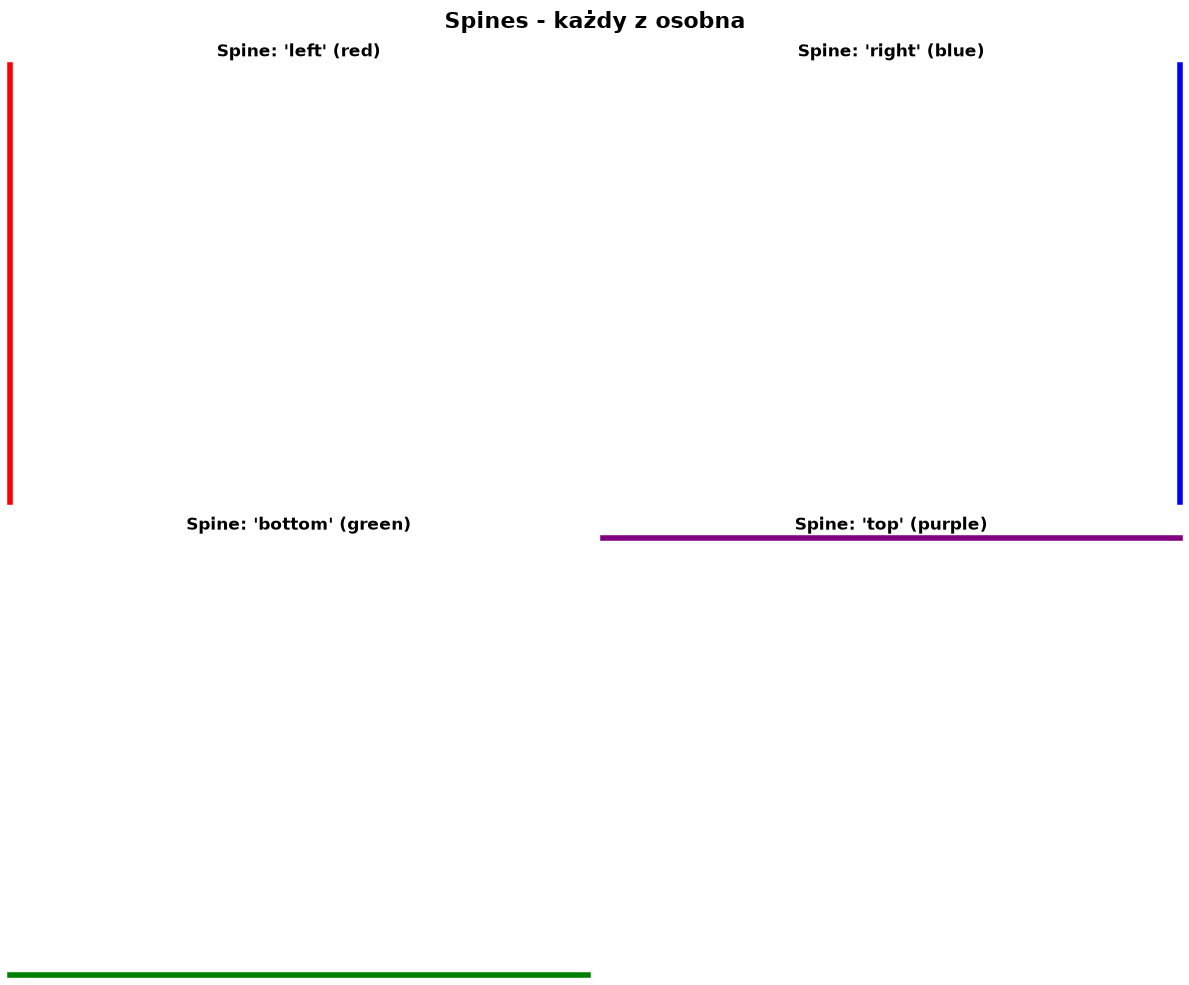

✅ Widzisz? Każdy Spine to jedna krawędź wykresu!


In [66]:
# === 2. WIZUALIZACJA - Każdy Spine osobno ===
print("🎨 Wizualizacja każdego Spine osobno\n")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Spines - każdy z osobna', fontsize=16, fontweight='bold')

spine_names = ['left', 'right', 'bottom', 'top']
colors = ['red', 'blue', 'green', 'purple']

for i, (ax, spine_name, color) in enumerate(zip(axes.flat, spine_names, colors)):
    # Ukryj wszystkie Spines
    for s in ['left', 'right', 'bottom', 'top']:
        ax.spines[s].set_visible(False)
    
    # Pokaż tylko jeden Spine - pogrubiony i kolorowy
    ax.spines[spine_name].set_visible(True)
    ax.spines[spine_name].set_linewidth(4)
    ax.spines[spine_name].set_edgecolor(color)
    
    ax.set_title(f"Spine: '{spine_name}' ({color})", fontsize=12, fontweight='bold')
    
    # Wyłącz ticke całkowicie - zarówno pozycje jak i linie
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(left=False, right=False, top=False, bottom=False,
                   labelleft=False, labelright=False, labeltop=False, labelbottom=False)

plt.tight_layout()
plt.show()

print("✅ Widzisz? Każdy Spine to jedna krawędź wykresu!")

---

**💡 Chcesz zobaczyć każdy Artist z osobna w izolacji?**

Przejdź do **[matplotlib_faq.ipynb](../matplotlib_faq.ipynb)** - sekcja 2: "Jakie są typy Artists i do czego służą?"  

Na końcu tej sekcji znajdziesz **wizualizację wszystkich 12 Artists** z wykresu - każdy pokazany osobno, żebyś zobaczył dokładnie z czego składa się wykres!

---

### Przykład 2: Modyfikujemy elementy wykresu precyzyjnie

Teraz użyjemy wiedzy o strukturze do precyzyjnej modyfikacji wykresu:

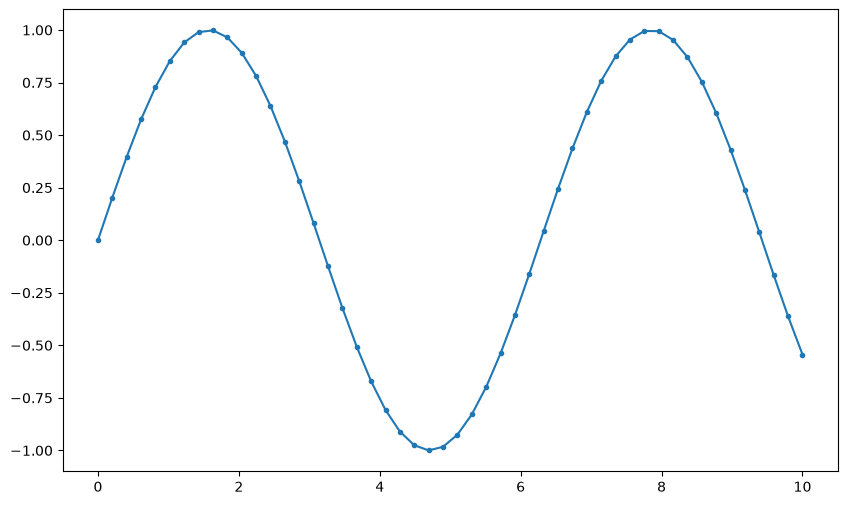

In [67]:
# === PRZYKŁAD: Modyfikujemy elementy wykresu ===

# Tworzymy wykres
fig, ax = plt.subplots(figsize=(10, 6))
x = np.linspace(0, 10, 50)
y = np.sin(x)

line, = ax.plot(x, y, marker='o', markersize=3)

plt.show()

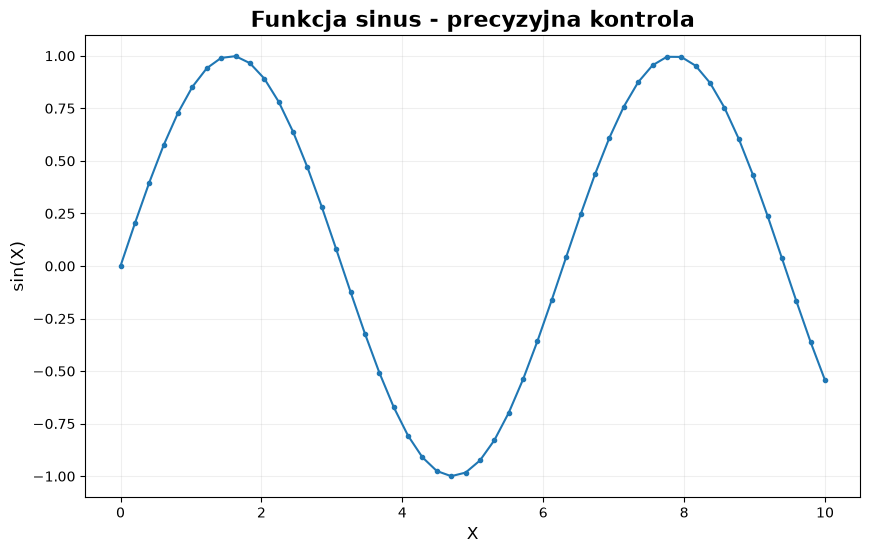

In [68]:
# Tworzymy wykres
fig, ax = plt.subplots(figsize=(10, 6))
x = np.linspace(0, 10, 50)
y = np.sin(x)

line, = ax.plot(x, y, marker='o', markersize=3)

# === 1. MODYFIKACJA PRZEZ AXES ===
ax.set_title('Funkcja sinus - precyzyjna kontrola', fontsize=16, fontweight='bold')
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('sin(X)', fontsize=12)
ax.grid(True, alpha=0.2)

plt.show()

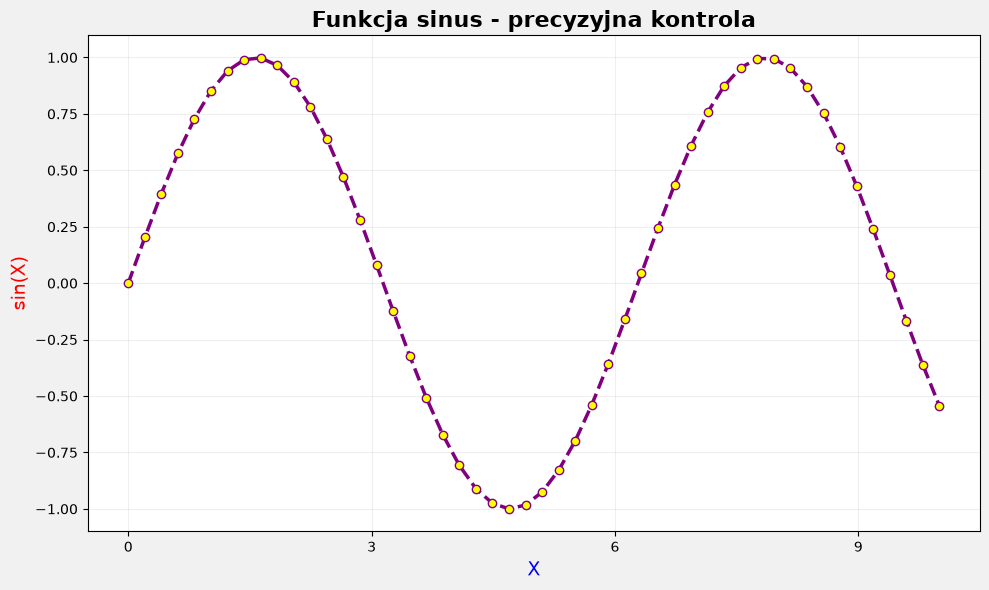


💡 ZASTOSOWALIŚMY:
   • Axes → tytuł, opisy osi, grid
   • Axis → kolory etykiet, podziałki
   • Artist (Line2D) → kolor, styl, markery
   • Figure → tło

✅ Precyzyjna kontrola każdego elementu!


In [80]:
# Tworzymy wykres
fig, ax = plt.subplots(figsize=(10, 6))
x = np.linspace(0, 10, 50)
y = np.sin(x)

line, = ax.plot(x, y, marker='o', markersize=3)

# === 1. MODYFIKACJA PRZEZ AXES ===
ax.set_title('Funkcja sinus - precyzyjna kontrola', fontsize=16, fontweight='bold')
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('sin(X)', fontsize=12)
ax.grid(True, alpha=0.2)

# === 2. MODYFIKACJA PRZEZ AXIS (precyzyjna kontrola osi) ===
# Dostęp do osi X
ax.xaxis.label.set_color('blue')
ax.xaxis.label.set_fontsize(14)

# Dostęp do osi Y
ax.yaxis.label.set_color('red')
ax.yaxis.label.set_fontsize(14)

# Ustaw podziałki co 2 na osi X
ax.xaxis.set_major_locator(plt.MultipleLocator(3))

# === 3. MODYFIKACJA PRZEZ ARTIST (precyzyjna kontrola linii) ===
line.set_color("purple")
line.set_linewidth(2.5)
line.set_linestyle('--')
line.set_marker('o')
line.set_markerfacecolor('yellow')
line.set_markersize(6)


# === 4. MODYFIKACJA FIGURE (rozmiar i tło) ===
fig.patch.set_facecolor("lightgray")
fig.patch.set_alpha(0.3)

plt.tight_layout()
plt.show()

print("\n💡 ZASTOSOWALIŚMY:")
print("   • Axes → tytuł, opisy osi, grid")
print("   • Axis → kolory etykiet, podziałki")
print("   • Artist (Line2D) → kolor, styl, markery")
print("   • Figure → tło")
print("\n✅ Precyzyjna kontrola każdego elementu!")

---
## Podsumowanie - Część 1

W tej części nauczyłeś się:

✅ **Podstaw Matplotlib:**
  - Instalacja i import biblioteki
  - Dwa style pracy: pyplot (MATLAB-style) vs object-oriented (OO-style)
  - Dlaczego używać stylu OO (pełna kontrola, brak niespodzianek)

✅ **Struktury Matplotlib:**
  - **Figure** - całe "płótno", kontener dla wykresów
  - **Axes** - konkretny wykres (jeden lub więcej na Figure)
  - **Axis** - osie X i Y (podziałki, etykiety, zakresy)
  - **Artists** - wszystkie elementy wykresu (Line2D, Spine, Text, itp.)

✅ **Praktycznych umiejętności:**
  - Eksploracja struktury wykresu (`fig`, `ax`, `ax.xaxis`, `ax.get_children()`)
  - Precyzyjna modyfikacja elementów (kolory, style, podziałki)
  - Wizualizacja poszczególnych Artists (np. Spines)
  - Dostęp do metadanych wykresu (rozmiar, DPI, tytuł, limity)

### Kluczowe wnioski:

- **Używaj OO-style** - jawne tworzenie obiektów daje pełną kontrolę
- **Struktura jest hierarchiczna** - Figure → Axes → Axis → Artists
- **Wszystko jest Artist** - każdy element można modyfikować
- **`subplots()` zwraca `(Figure, Axes)`** - podstawowa metoda tworzenia wykresów

### Co dalej?

W **Części 2** nauczysz się:
- Tworzenia wykresów liniowych (`plot`)
- Tworzenia wykresów słupkowych (`bar`, `barh`)
- Wykresów grupowanych i skumulowanych
- Praktycznych zastosowań na rzeczywistych danych

**Gotowy na więcej? Przejdź do Part 2!** 🚀